# Heart Disease Prediction — Kaggle Playground S6E2

**Goal:** Predict the presence or absence of heart disease from clinical features.  
**Metric:** ROC-AUC (higher is better, max = 1.0)  
**Approach:** First-principles learning — understand why before how.

---

## How to read this notebook

Every section starts with an explanation block (like this one) that answers:  
- **What** are we doing?  
- **Why** does it matter?  
- **What should we expect** to find?

Then comes the code. Read the explanation first, then run the code, then think about what you see.

---
# Phase 1 — Exploratory Data Analysis (EDA)

**First principle:** Never touch a model before you understand your data.  

EDA is not optional cleanup — it is *the most important step*. It tells you:  
1. Are there data quality issues? (missing values, outliers, wrong types)  
2. What does the target distribution look like? (balanced? skewed?)  
3. Which features are informative? (do they vary with the target?)  
4. Are features correlated with each other? (multicollinearity)  

Everything you find here shapes your modelling decisions.

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print('Libraries loaded.')

Libraries loaded.


## 1.1 — Load the Data

Always start by just *looking* at the raw data.  
Check: shape, column names, dtypes, and the first few rows.

In [2]:
DATA_DIR = 'Dataset/'

train = pd.read_csv(DATA_DIR + 'train.csv')
test  = pd.read_csv(DATA_DIR + 'test.csv')
sub   = pd.read_csv(DATA_DIR + 'sample_submission.csv')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'Submission  : {sub.shape}')

train.head()

Train shape : (630000, 15)
Test shape  : (270000, 14)
Submission  : (270000, 2)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.600,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.000,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.000,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.000,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.800,2,3,3,Presence


In [3]:
# Data types and memory usage
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Heart Disease  

## 1.2 — Missing Values

**Why this matters:** Most ML algorithms cannot handle NaN values — they'll error out or silently produce garbage predictions.  
We need to know *how many* values are missing and *which features* have them before deciding how to handle them.

Strategies (we'll choose based on what we find):  
- **Drop rows** — only if very few rows are affected  
- **Fill with median/mode** — simple and usually fine for tree-based models  
- **Fill with model** — overkill for most cases

In [4]:
missing_train = train.isnull().sum()
missing_test  = test.isnull().sum()

missing = pd.DataFrame({
    'Train Missing'  : missing_train,
    'Train %'        : (missing_train / len(train) * 100).round(2),
    'Test Missing'   : missing_test,
    'Test %'         : (missing_test  / len(test)  * 100).round(2),
})

missing[missing['Train Missing'] > 0]

,Train Missing,Train %,Test Missing,Test %


In [5]:
# Summary statistics — check for unusual min/max values
train.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000,630000.000
mean,314999.500,54.137,0.715,3.313,130.497,245.012,0.080,0.982,152.817,0.274,0.716,1.456,0.451,4.619
std,181865.479,8.256,0.452,0.852,14.976,33.682,0.271,0.999,19.113,0.446,0.948,0.545,0.799,1.950
min,0.000,29.000,0.000,1.000,94.000,126.000,0.000,0.000,71.000,0.000,0.000,1.000,0.000,3.000
25%,157499.750,48.000,0.000,3.000,120.000,223.000,0.000,0.000,142.000,0.000,0.000,1.000,0.000,3.000
50%,314999.500,54.000,1.000,4.000,130.000,243.000,0.000,0.000,157.000,0.000,0.100,1.000,0.000,3.000
75%,472499.250,60.000,1.000,4.000,140.000,269.000,0.000,2.000,166.000,1.000,1.400,2.000,1.000,7.000
max,629999.000,77.000,1.000,4.000,200.000,564.000,1.000,2.000,202.000,1.000,6.200,3.000,3.000,7.000


## 1.3 — Target Distribution

**Why this matters:** If 95% of patients have "Absence" and only 5% have "Presence",  
a model that always predicts "Absence" would be 95% accurate — but completely useless.  

Class imbalance affects:  
- Which metric to use (ROC-AUC is robust to imbalance; accuracy is not)  
- Whether we need to oversample/undersample  
- How we interpret model outputs

Target distribution:
         Count  Percent
target                 
0       347546   55.200
1       282454   44.800


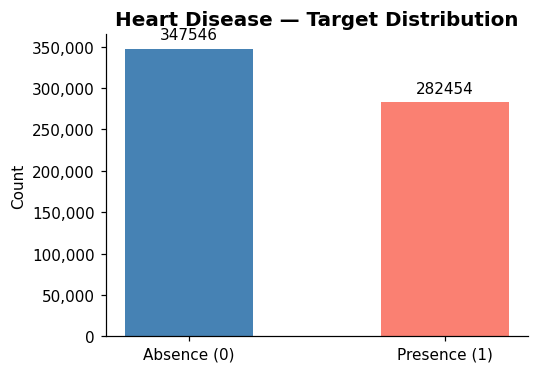

In [6]:
# Encode target: Presence=1, Absence=0
train['target'] = (train['Heart Disease'] == 'Presence').astype(int)

counts = train['target'].value_counts()
pct    = train['target'].value_counts(normalize=True) * 100

print('Target distribution:')
print(pd.DataFrame({'Count': counts, 'Percent': pct.round(1)}))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['Absence (0)', 'Presence (1)'], counts.sort_index(), color=['steelblue', 'salmon'], width=0.5)
ax.bar_label(ax.containers[0], fmt='%d', padding=4, fontsize=10)
ax.set_title('Heart Disease — Target Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 1.4 — Feature Reference

Before visualizing, let's understand what each feature *means* clinically.  
This matters because domain knowledge guides feature engineering decisions later.

| Feature | Type | Medical Meaning |
|---|---|---|
| Age | Continuous | Patient age in years — older = higher risk |
| Sex | Binary | 1 = Male, 0 = Female — men have higher risk at younger ages |
| Chest pain type | Categorical | 1=typical angina, 2=atypical, 3=non-anginal, 4=asymptomatic |
| BP | Continuous | Resting blood pressure (mmHg) — high BP is a risk factor |
| Cholesterol | Continuous | Serum cholesterol mg/dl — high levels clog arteries |
| FBS over 120 | Binary | Fasting blood sugar > 120 mg/dl — proxy for diabetes |
| EKG results | Categorical | Electrical heart activity: 0=normal, 1=ST-T wave abnormality, 2=LV hypertrophy |
| Max HR | Continuous | Max heart rate achieved — lower max HR can indicate disease |
| Exercise angina | Binary | Chest pain during exercise — strong signal |
| ST depression | Continuous | ECG drop during exercise — important cardiac marker |
| Slope of ST | Categorical | 1=upsloping (good), 2=flat, 3=downsloping (bad) |
| Number of vessels fluro | Continuous | 0–3 vessels visible on fluoroscopy — more = more disease |
| Thallium | Categorical | Blood flow scan: 3=normal, 6=fixed defect, 7=reversible defect |

## 1.5 — Feature Distributions

**What to look for:**  
- **Continuous features:** Are they roughly normal? Skewed? Any extreme outliers?  
- **Categorical features:** Are all expected values present? Any unexpected values?  
- **Do distributions shift between the 0 and 1 class?** This is the core signal.

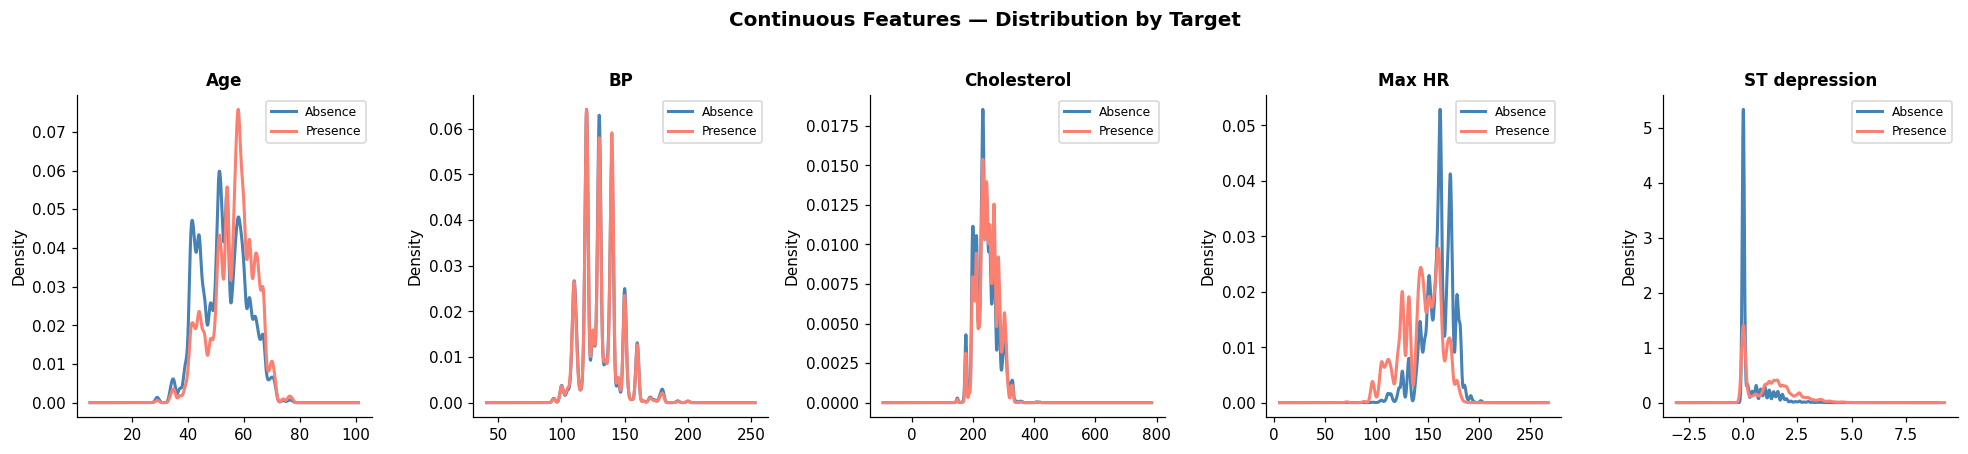

In [7]:
# Split feature names by type
CONTINUOUS   = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
CATEGORICAL  = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
                'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

# Continuous features — KDE split by target
fig, axes = plt.subplots(1, len(CONTINUOUS), figsize=(18, 4))
for ax, col in zip(axes, CONTINUOUS):
    for val, label, color in [(0, 'Absence', 'steelblue'), (1, 'Presence', 'salmon')]:
        subset = train.loc[train['target'] == val, col]
        subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
fig.suptitle('Continuous Features — Distribution by Target', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

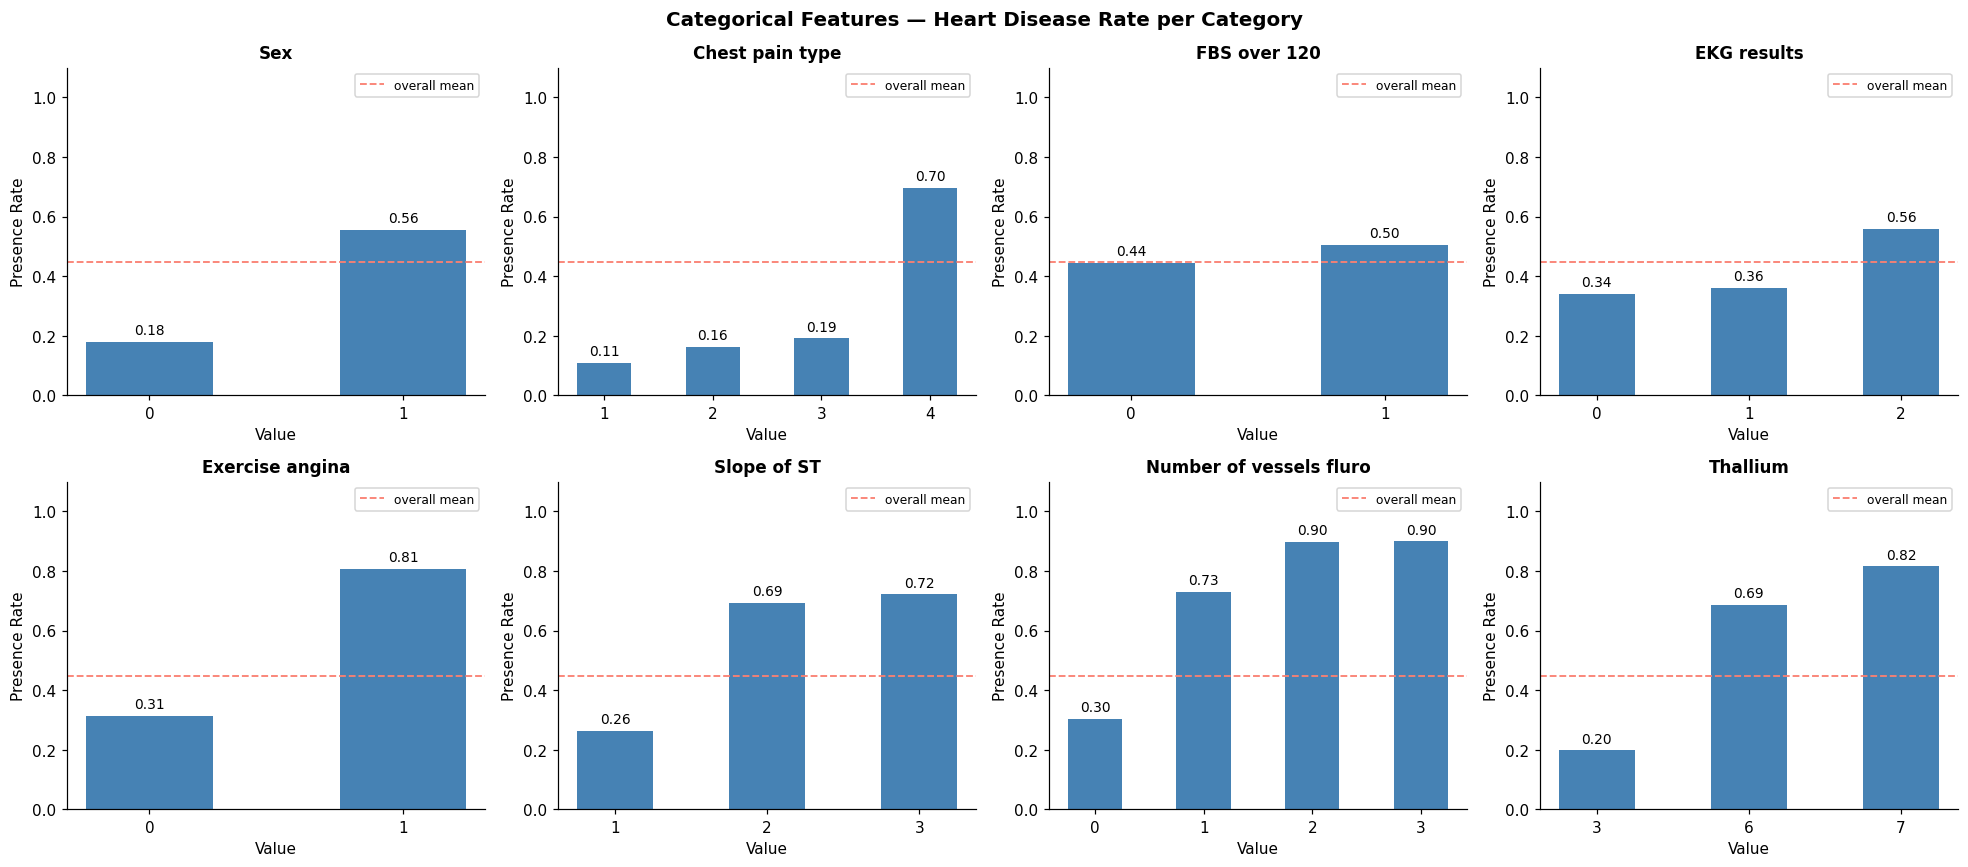

In [8]:
# Categorical features — Disease rate per category value
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, CATEGORICAL):
    rate = train.groupby(col)['target'].mean().sort_index()
    bars = ax.bar(rate.index.astype(str), rate.values, color='steelblue', width=0.5)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Presence Rate')
    ax.set_xlabel('Value')
    ax.axhline(train['target'].mean(), color='salmon', linestyle='--', linewidth=1.2, label='overall mean')
    ax.legend(fontsize=8)

fig.suptitle('Categorical Features — Heart Disease Rate per Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.6 — Correlation Analysis

**Pearson correlation with target** tells us: for continuous features, which direction does the feature move as disease risk increases?  

Limitations to keep in mind:  
- Pearson only captures *linear* relationships — a feature can be important even with low correlation  
- Correlated features carry redundant information (but tree models handle this fine)  

**Point-biserial correlation** is the right term when one variable is binary — but numerically it equals Pearson, so we use `.corr()` directly.

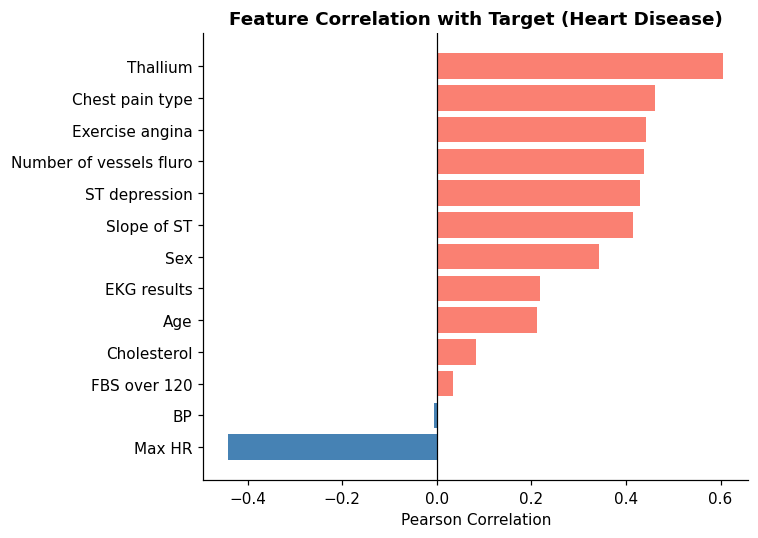


Top positive correlators (increase disease risk):
ST depression             0.431
Number of vessels fluro   0.439
Exercise angina           0.442
Chest pain type           0.461
Thallium                  0.606

Top negative correlators (decrease disease risk):
Max HR   -0.441
BP       -0.005


In [9]:
# Encode categoricals as integers for correlation
feature_cols = CONTINUOUS + CATEGORICAL
corr_with_target = train[feature_cols + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['salmon' if v > 0 else 'steelblue' for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target (Heart Disease)', fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('\nTop positive correlators (increase disease risk):')
print(corr_with_target[corr_with_target > 0].tail(5).to_string())
print('\nTop negative correlators (decrease disease risk):')
print(corr_with_target[corr_with_target < 0].head(5).to_string())

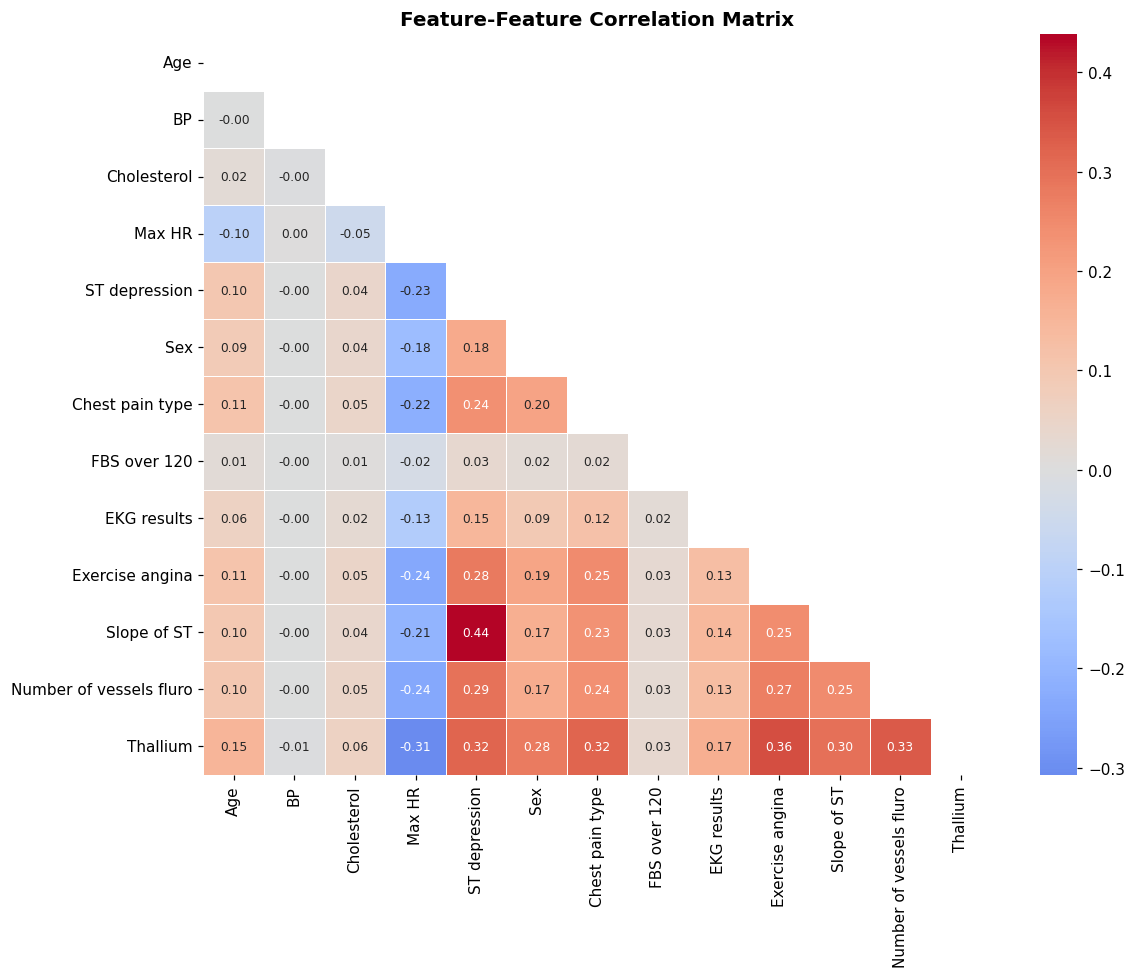

In [10]:
# Feature-feature correlation heatmap
# Why: if two features are highly correlated (e.g. > 0.8), they carry near-identical information.
# This doesn't hurt tree models but is important to know.

corr_matrix = train[feature_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Feature-Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.7 — Distribution Shift: Train vs Test

**Why this matters:** If the test data has a different distribution than train data, your model may not generalize well.  
This is called **covariate shift** — the inputs changed even if the underlying relationship didn't.

We check this by comparing the mean and std of each feature across train and test.

In [11]:
train_stats = train[feature_cols].agg(['mean', 'std']).T.rename(columns={'mean': 'train_mean', 'std': 'train_std'})
test_stats  = test[feature_cols].agg(['mean', 'std']).T.rename(columns={'mean': 'test_mean',  'std': 'test_std'})

shift = pd.concat([train_stats, test_stats], axis=1)
shift['mean_diff_%'] = ((shift['test_mean'] - shift['train_mean']) / shift['train_mean'].abs().clip(lower=1e-6) * 100).round(2)

shift.sort_values('mean_diff_%', key=abs, ascending=False)

,train_mean,train_std,test_mean,test_std,mean_diff_%
Number of vessels fluro,0.451,0.799,0.455,0.801,0.830
Exercise angina,0.274,0.446,0.275,0.446,0.340
EKG results,0.982,0.999,0.978,0.999,-0.320
ST depression,0.716,0.948,0.718,0.947,0.290
Slope of ST,1.456,0.545,1.459,0.546,0.240
Sex,0.715,0.452,0.716,0.451,0.220
FBS over 120,0.080,0.271,0.080,0.271,0.080
Chest pain type,3.313,0.852,3.315,0.852,0.070
Age,54.137,8.256,54.160,8.255,0.040
BP,130.497,14.976,130.555,15.008,0.040


## 1.8 — EDA Summary

Fill in after running the cells above.

**Class balance:**  
- *(e.g. roughly balanced / imbalanced at X%)*

**Missing values:**  
- *(e.g. none / feature X has Y% missing)*

**Strongest predictors (from correlation chart):**  
- Positive (increase risk): *...*  
- Negative (decrease risk): *...*

**Notable patterns:**  
- *(e.g. Chest pain type 4 = asymptomatic has highest disease rate, which is counterintuitive — investigate)*

**Distribution shift between train and test:**  
- *(e.g. minimal / feature X shows notable shift)*

**Decisions for modelling:**  
- [ ] Encode target as 0/1  
- [ ] Handle any missing values  
- [ ] All features are already numeric — no text encoding needed  
- [ ] *(anything else you discovered)*

---
# Phase 2 — Baseline Model: Logistic Regression

**First principle:** Before reaching for powerful models, build the *simplest possible* model first.

Logistic Regression is our baseline for three reasons:
1. **Interpretable** — every coefficient has a direct, numeric meaning (log-odds)
2. **Fast** — trains in seconds even on 630K rows
3. **Sets the bar** — any more complex model must beat this score to justify its added complexity

Sections in this phase:
- **2.1** The math: sigmoid, log-odds, decision boundary
- **2.2** Cross-validation: why a single split isn't enough
- **2.3** ROC-AUC: what it actually measures
- **2.4** Confusion matrix and the precision-recall tradeoff
- **2.5** Coefficient interpretation: which features drive the prediction?
- **2.6** Summary and baseline score

## 2.1 — The Math: Why Does Logistic Regression Work?

### The core problem
Linear regression predicts a number on (−∞, +∞). But we need a *probability* in [0, 1].  
The fix: squash the linear output through the **sigmoid function**:

```
σ(z) = 1 / (1 + e^(-z))      where z = w₀ + w₁x₁ + w₂x₂ + ...
```

No matter how large or small `z` is, `σ(z)` always lands in (0, 1). That's our predicted probability.

### Log-odds (the "logit")
Rearranging: `z = log(p / (1−p))` — the *log of the odds ratio*.  
A coefficient `w₁` means: **each 1-unit increase in x₁ changes the log-odds of disease by w₁**.  
Exponentiate it (`e^w₁`) and you get the **odds ratio** — how many times more likely disease becomes.

### Decision boundary
Logistic regression predicts class 1 when `σ(z) ≥ 0.5`, which means `z ≥ 0`.  
In 2D feature space, `z = 0` is a *straight line* — this is a **linear classifier**.  
Key limitation: if the true boundary is curved, logistic regression cannot capture it.

### What it optimizes
It minimizes **binary cross-entropy** (log-loss):
```
Loss = −[y·log(p) + (1−y)·log(1−p)]
```
When the true label is 1 and we predict p≈0 (very confident and wrong), log(p) → −∞ → huge penalty.  
This asymmetric penalty forces the model to be well-calibrated, not just accurate.

### Feature scaling is required
The gradient descent optimizer that fits the weights is sensitive to the *scale* of features.  
If `Age` ranges 29–77 and `ST depression` ranges 0–6.2, the optimizer has to take very different-sized steps.  
**StandardScaler** (subtract mean, divide by std) puts all features on the same scale → faster convergence, better numerical stability.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Feature columns (same order as EDA)
FEATURE_COLS = [
    'Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression',      # continuous
    'Sex', 'Chest pain type', 'FBS over 120', 'EKG results',    # categorical (already int)
    'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium'
]

X = train[FEATURE_COLS].values
y = train['target'].values   # already encoded in Phase 1: 1=Presence, 0=Absence

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Positive rate : {y.mean():.3f}  ({y.sum():,} / {len(y):,})')
print()

# Visualise why scaling matters
raw_stats = train[FEATURE_COLS].agg(['min', 'max', 'std'])
print('Feature ranges BEFORE scaling:')
print(raw_stats.T.to_string())

X shape : (630000, 13)
y shape : (630000,)
Positive rate : 0.448  (282,454 / 630,000)

Feature ranges BEFORE scaling:
                            min     max    std
Age                      29.000  77.000  8.256
BP                       94.000 200.000 14.976
Cholesterol             126.000 564.000 33.682
Max HR                   71.000 202.000 19.113
ST depression             0.000   6.200  0.948
Sex                       0.000   1.000  0.452
Chest pain type           1.000   4.000  0.852
FBS over 120              0.000   1.000  0.271
EKG results               0.000   2.000  0.999
Exercise angina           0.000   1.000  0.446
Slope of ST               1.000   3.000  0.545
Number of vessels fluro   0.000   3.000  0.799
Thallium                  3.000   7.000  1.950


## 2.2 — Cross-Validation: Why One Split Is Not Enough

### The problem with a single train/val split
If you split 80% train / 20% val and get AUC = 0.87, is that trustworthy?  
Maybe you got lucky: your 20% happened to be easy to predict.  
Or unlucky: your 20% was unusually hard. You have no way to know.

### 5-Fold Stratified Cross-Validation
We split the data into 5 equal-sized **folds**. In each round:
- 4 folds = training set
- 1 fold = validation set (the model has *never seen this data*)

Repeat 5 times so every row appears in the validation set exactly once.  
Average the 5 AUC scores → much more stable estimate of true model performance.

**Stratified** means each fold has the same class ratio as the full dataset.  
This matters for imbalanced problems (though ours is nearly balanced).

### Out-of-Fold (OOF) predictions
Collecting the val-fold predictions across all 5 rounds gives us **OOF predictions** —  
a valid predicted probability for every single training row, with **zero data leakage**.

OOF predictions are gold: we use them later to blend models in Phase 5.

In [13]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(y))   # will hold OOF probabilities for every training row
fold_aucs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # Scale INSIDE the fold — fit scaler only on train, apply to val
    # (fitting on all data would leak val statistics into training)
    scaler = StandardScaler()
    X_tr_scaled  = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    model.fit(X_tr_scaled, y_tr)

    val_proba = model.predict_proba(X_val_scaled)[:, 1]  # P(class=1)
    oof_preds[val_idx] = val_proba

    fold_auc = roc_auc_score(y_val, val_proba)
    fold_aucs.append(fold_auc)
    print(f'  Fold {fold}  |  val AUC = {fold_auc:.5f}  |  val rows = {len(val_idx):,}')

oof_auc = roc_auc_score(y, oof_preds)
print(f'\n  Mean fold AUC : {np.mean(fold_aucs):.5f}  ±  {np.std(fold_aucs):.5f}')
print(f'  OOF AUC       : {oof_auc:.5f}  ← use this as the single summary score')

  Fold 1  |  val AUC = 0.95075  |  val rows = 126,000
  Fold 2  |  val AUC = 0.94996  |  val rows = 126,000


  Fold 3  |  val AUC = 0.95078  |  val rows = 126,000
  Fold 4  |  val AUC = 0.95022  |  val rows = 126,000


  Fold 5  |  val AUC = 0.95074  |  val rows = 126,000

  Mean fold AUC : 0.95049  ±  0.00034
  OOF AUC       : 0.95049  ← use this as the single summary score


## 2.3 — ROC-AUC: What Does It Actually Measure?

### The ROC curve
At every possible **threshold** t (from 0 → 1), we ask:
- "If I predict disease when predicted probability ≥ t, what's my True Positive Rate (TPR) and False Positive Rate (FPR)?"

**TPR** (Recall/Sensitivity) = of all real positives, how many did we catch?  
**FPR** = of all real negatives, how many did we falsely flag?

Sweeping t from 1 → 0 traces a curve from (0,0) to (1,1).  
A perfect model: TPR=1, FPR=0, curve hugs the top-left corner.  
A random model: diagonal line (TPR ≈ FPR always), AUC = 0.5.

### AUC (Area Under the Curve)
A single number summary: the probability that a **randomly chosen positive** patient gets a higher predicted score than a **randomly chosen negative** patient.

- AUC = 1.0 → perfect separation
- AUC = 0.5 → random (useless)
- AUC = 0.9 → very strong
- AUC = 0.75 → decent, room to improve

AUC is **threshold-independent** — it evaluates the quality of the *ranking*, not any specific cutoff.  
This is exactly why Kaggle uses it: you submit probabilities, not hard labels.

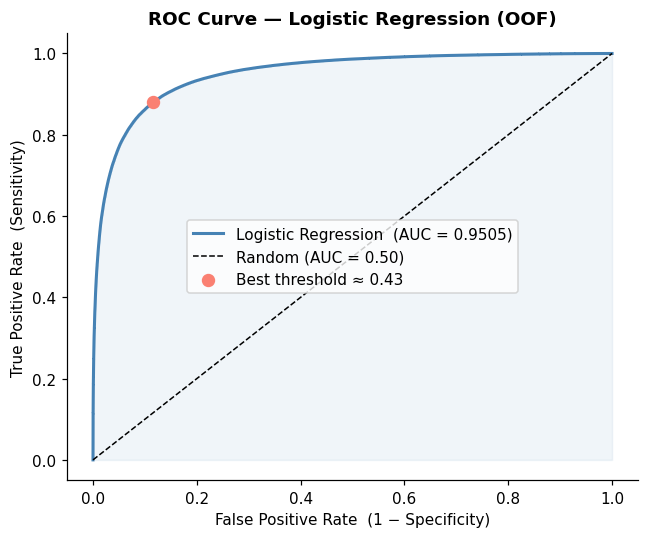

Optimal threshold (min distance to top-left): 0.431
  TPR at that point : 0.880
  FPR at that point : 0.116


In [14]:
# ROC curve from OOF predictions (the most honest estimate we have)
fpr, tpr, thresholds = roc_curve(y, oof_preds)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Logistic Regression  (AUC = {oof_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')

# Mark the "optimal" operating point — closest to top-left
dist_to_corner = np.sqrt((fpr)**2 + (1 - tpr)**2)
best_idx = np.argmin(dist_to_corner)
ax.scatter(fpr[best_idx], tpr[best_idx], color='salmon', zorder=5, s=60,
           label=f'Best threshold ≈ {thresholds[best_idx]:.2f}')

ax.set_xlabel('False Positive Rate  (1 − Specificity)')
ax.set_ylabel('True Positive Rate  (Sensitivity)')
ax.set_title('ROC Curve — Logistic Regression (OOF)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Optimal threshold (min distance to top-left): {thresholds[best_idx]:.3f}')
print(f'  TPR at that point : {tpr[best_idx]:.3f}')
print(f'  FPR at that point : {fpr[best_idx]:.3f}')

## 2.4 — Confusion Matrix and the Precision-Recall Tradeoff

### The four outcomes at a fixed threshold
Once you pick a threshold (e.g. 0.5), every prediction is either:

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| **True 0** | True Negative (TN) ✓ | False Positive (FP) ✗ |
| **True 1** | False Negative (FN) ✗ | True Positive (TP) ✓ |

**False Negative** = missed a sick patient → dangerous in medicine.  
**False Positive** = healthy patient flagged → costly in over-treatment.

### Precision vs Recall
- **Precision** = TP / (TP + FP) — of patients we flagged, how many are truly sick?
- **Recall** = TP / (TP + FN) — of all truly sick patients, how many did we catch?

**There is always a tradeoff:** lower the threshold → more positives flagged → recall ↑, precision ↓.  
Which matters more depends on the *cost* of each error type. In heart disease screening, missing a case (FN) is usually worse than an unnecessary follow-up (FP), so we prefer **high recall**.

Note: for Kaggle submission we submit probabilities and Kaggle picks the threshold — so AUC is what counts.  
But the confusion matrix helps us understand *where* the model is making mistakes.

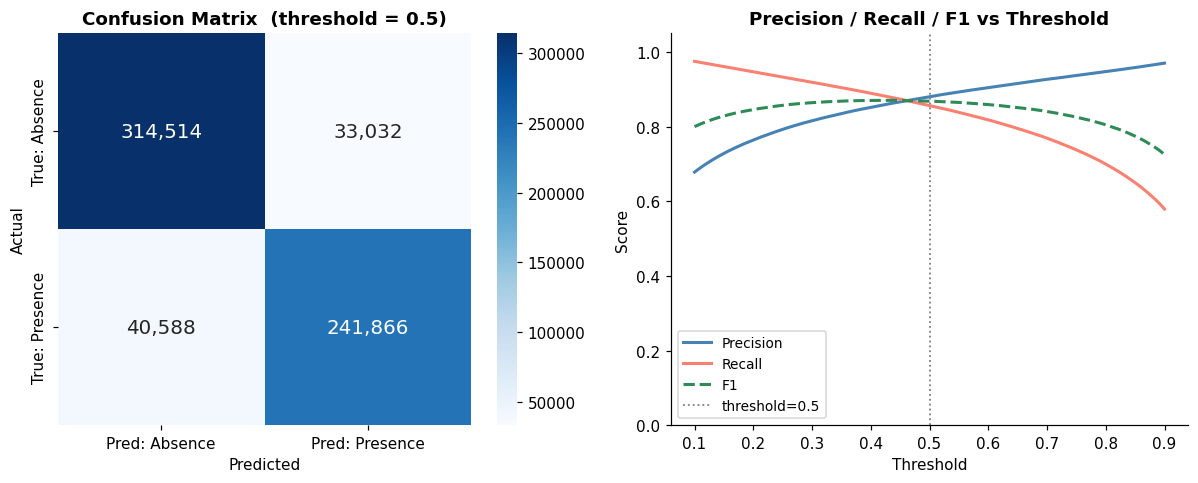


Classification report at threshold = 0.5:
              precision    recall  f1-score   support

     Absence       0.89      0.90      0.90    347546
    Presence       0.88      0.86      0.87    282454

    accuracy                           0.88    630000
   macro avg       0.88      0.88      0.88    630000
weighted avg       0.88      0.88      0.88    630000



In [15]:
# Use OOF predictions with threshold = 0.5
oof_labels = (oof_preds >= 0.5).astype(int)
cm = confusion_matrix(y, oof_labels)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Confusion matrix heatmap ---
ax = axes[0]
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Absence', 'Pred: Presence'],
            yticklabels=['True: Absence', 'True: Presence'],
            annot_kws={'size': 13})
ax.set_title('Confusion Matrix  (threshold = 0.5)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# --- Precision-Recall tradeoff across thresholds ---
ax = axes[1]
thresh_vals = np.linspace(0.1, 0.9, 200)
precisions, recalls, f1s = [], [], []
for t in thresh_vals:
    preds_t = (oof_preds >= t).astype(int)
    if preds_t.sum() == 0:
        precisions.append(np.nan); recalls.append(np.nan); f1s.append(np.nan)
        continue
    p = tp_t = ((preds_t == 1) & (y == 1)).sum() / preds_t.sum()
    r = tp_t2 = ((preds_t == 1) & (y == 1)).sum() / y.sum()
    precisions.append(p); recalls.append(r)
    f1s.append(2*p*r/(p+r) if (p+r) > 0 else 0)

ax.plot(thresh_vals, precisions, label='Precision', color='steelblue', lw=2)
ax.plot(thresh_vals, recalls,   label='Recall',    color='salmon',    lw=2)
ax.plot(thresh_vals, f1s,       label='F1',        color='seagreen',  lw=2, linestyle='--')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.2, label='threshold=0.5')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print('\nClassification report at threshold = 0.5:')
print(classification_report(y, oof_labels, target_names=['Absence', 'Presence']))

## 2.5 — Interpreting the Coefficients

### What each coefficient tells you
The trained weights `w₁, w₂, ...` are the *coefficients* of the linear combination `z = Σ wᵢxᵢ`.

Because we scaled all features to mean=0, std=1 before training:
- Coefficients are **directly comparable** — a larger |w| means stronger influence.
- **Positive w** → feature increases the log-odds of Presence (disease more likely).
- **Negative w** → feature decreases the log-odds of Presence (disease less likely).

To convert to odds ratios: `OR = e^w`.  
OR > 1 → feature increases odds; OR < 1 → feature decreases odds.

### What we expect to see (from EDA)
From Phase 1 we found that high ST depression, asymptomatic chest pain (type 4), more vessels fluoro'd, and reversible Thallium defect all correlated with disease presence.  
If LR learned correctly, these features should have the largest positive coefficients.

                Feature  Coefficient  Odds Ratio
                 Max HR       -0.838       0.433
           FBS over 120       -0.011       0.989
                     BP        0.004       1.004
            Cholesterol        0.097       1.102
            EKG results        0.219       1.245
                    Age        0.352       1.422
            Slope of ST        0.444       1.559
          ST depression        0.462       1.588
                    Sex        0.483       1.622
        Exercise angina        0.542       1.719
Number of vessels fluro        0.705       2.025
        Chest pain type        0.888       2.431
               Thallium        0.963       2.621

Intercept: -0.2789


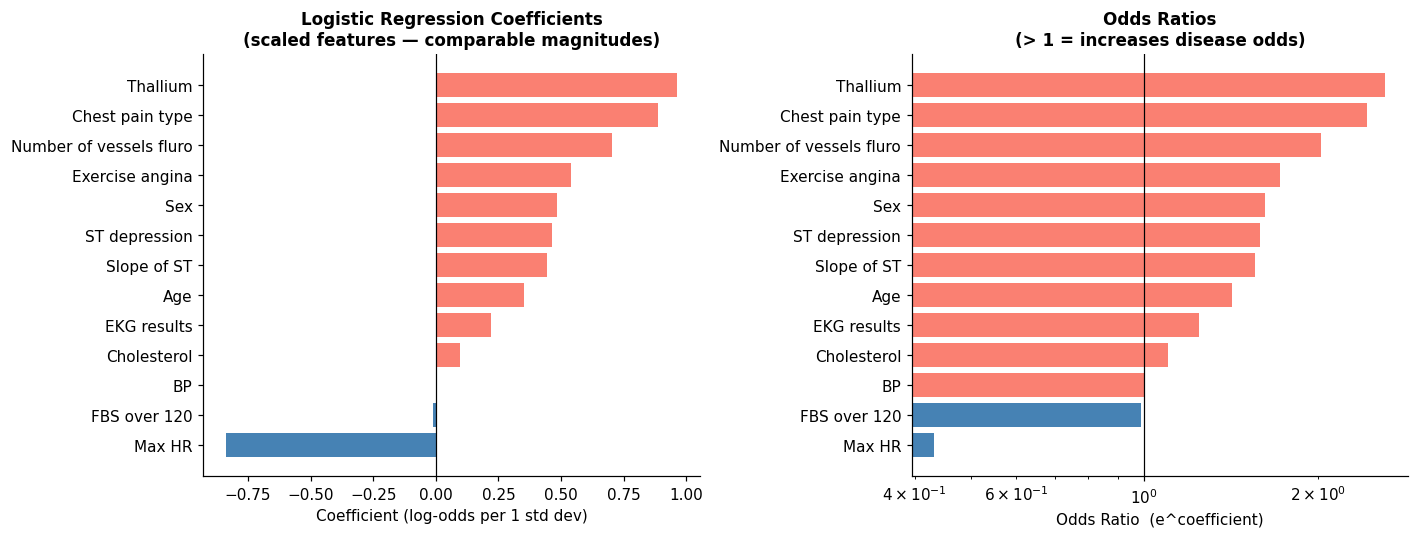

In [16]:
# Train final model on ALL training data (for coefficient inspection and test predictions)
final_scaler = StandardScaler()
X_scaled_all = final_scaler.fit_transform(X)

final_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
final_model.fit(X_scaled_all, y)

# Build coefficient table
coef_df = pd.DataFrame({
    'Feature'      : FEATURE_COLS,
    'Coefficient'  : final_model.coef_[0],
    'Odds Ratio'   : np.exp(final_model.coef_[0])
}).sort_values('Coefficient')

print(coef_df.to_string(index=False))
print(f'\nIntercept: {final_model.intercept_[0]:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coefficient bar chart
ax = axes[0]
colors = ['salmon' if v > 0 else 'steelblue' for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(scaled features — comparable magnitudes)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Coefficient (log-odds per 1 std dev)')

# Odds ratio bar chart (log scale makes it symmetric around 1)
ax = axes[1]
colors2 = ['salmon' if v > 1 else 'steelblue' for v in coef_df['Odds Ratio']]
ax.barh(coef_df['Feature'], coef_df['Odds Ratio'], color=colors2)
ax.axvline(1, color='black', linewidth=0.8)
ax.set_title('Odds Ratios\n(> 1 = increases disease odds)', fontsize=11, fontweight='bold')
ax.set_xlabel('Odds Ratio  (e^coefficient)')
ax.set_xscale('log')

plt.tight_layout()
plt.show()

## 2.6 — Generate Test Predictions

Before summarizing, let's produce test-set probabilities from the final model.  
These are what we'd submit to Kaggle (we'll do the actual submission in Phase 5 after blending).

Test predictions shape : (270000,)
Test pred mean         : 0.4497
Test pred range        : [0.0002, 1.0000]


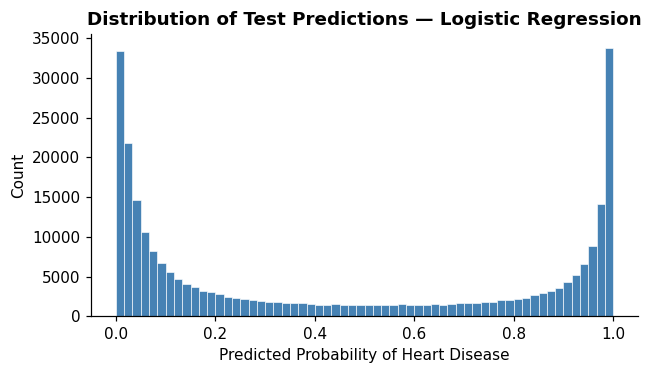

In [17]:
X_test = test[FEATURE_COLS].values
X_test_scaled = final_scaler.transform(X_test)   # use scaler fit on full train — no leakage

lr_test_preds = final_model.predict_proba(X_test_scaled)[:, 1]

print(f'Test predictions shape : {lr_test_preds.shape}')
print(f'Test pred mean         : {lr_test_preds.mean():.4f}')
print(f'Test pred range        : [{lr_test_preds.min():.4f}, {lr_test_preds.max():.4f}]')

# Quick sanity check: distribution of test predictions
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(lr_test_preds, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Predicted Probability of Heart Disease')
ax.set_ylabel('Count')
ax.set_title('Distribution of Test Predictions — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

## 2.7 — Phase 2 Summary

**Baseline OOF ROC-AUC: 0.9505** (std ±0.0003 — very stable across folds)

**What the model learned (from coefficients):**
- Strongest risk-increasing: **Thallium** (OR 2.62), **Chest pain type** (OR 2.43), **# vessels fluoro** (OR 2.03)
- Strongest risk-decreasing: **Max HR** (OR 0.43) — lower max heart rate → more disease
- Matches EDA perfectly ✓

**Confusion matrix at threshold 0.5:**
- Precision 88–89%, Recall 86–90%, Accuracy 88%
- Optimal threshold is ~0.431 (not 0.5) — model is slightly under-confident

**Key limitations of logistic regression (to fix in Phase 3):**
- Only captures *linear* relationships — if Max HR has a non-monotonic effect, LR misses it
- Features interact *additively* only — can't learn "ST depression matters more when # vessels > 1"
- All 13 features contribute; LR cannot automatically ignore noise

**Baseline to beat: 0.9505**

---
# Phase 3 — Tree-Based Models (Decision Tree → Random Forest)

*(Coming next)*

---
# Phase 3 — Tree-Based Models: Decision Tree → Random Forest

**Why move beyond logistic regression?**  
LR draws a *straight-line* boundary in feature space. Real data has curved, interacting patterns.  
Trees can learn "if Thallium=7 AND # vessels > 1 AND ST depression > 1.5 → very high risk" — no straight line can do that.

Sections in this phase:
- **3.1** Decision Trees: how splits work, Gini impurity, depth vs overfitting
- **3.2** Visualizing what a tree actually learned
- **3.3** Random Forest: why averaging many trees beats one tree
- **3.4** 5-fold CV and OOF AUC — does RF beat the 0.9505 baseline?
- **3.5** Feature importances: what the forest relies on
- **3.6** Summary and comparison

## 3.1 — Decision Trees: How Splits Work

### The core idea: recursive binary splitting
A decision tree asks a yes/no question at each node: "Is feature X ≤ threshold t?"  
It picks the question that best separates the two classes, then repeats on each side.

### How does it pick the best split?
It minimizes **Gini impurity** — a measure of how mixed the classes are in a node.

```
Gini(node) = 1 − (p₀² + p₁²)
```
where p₀, p₁ are the fraction of class 0 and class 1 samples in that node.

- Pure node (all one class): Gini = 0  (best)
- Fully mixed (50/50): Gini = 0.5  (worst)

At each potential split, the tree computes the **weighted average Gini** of the two child nodes  
and picks the (feature, threshold) pair that minimizes it.

### The depth problem
- **Depth = 1**: asks only 1 question — underfits, misses most signal (high bias)
- **Depth = 20**: asks 20 questions per path — memorizes training noise (high variance, overfits)
- **Sweet spot**: some intermediate depth generalizes to new data

This is the **bias-variance tradeoff** made visible.  
The plot below shows train AUC vs validation AUC as depth increases — watch them diverge.

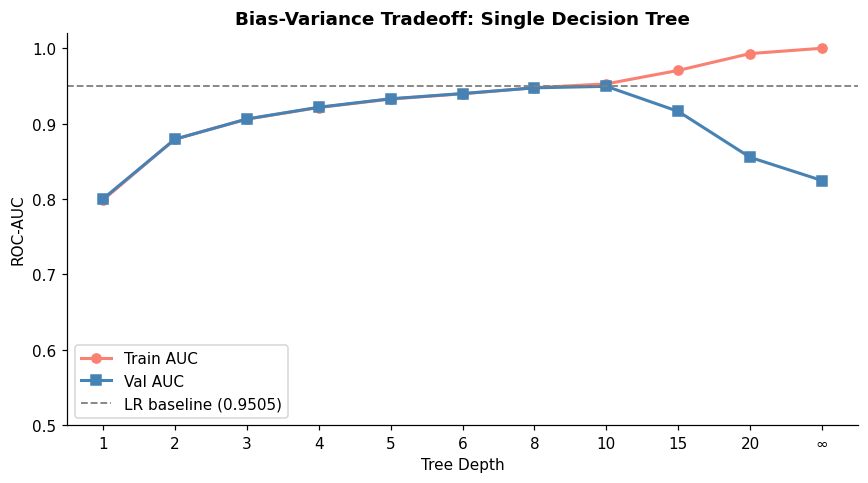

   Depth   Train AUC     Val AUC       Gap
------------------------------------------
       1     0.79869     0.80025  -0.00156
       2     0.87945     0.87930   0.00015
       3     0.90596     0.90615  -0.00019
       4     0.92137     0.92174  -0.00037
       5     0.93261     0.93301  -0.00040
       6     0.93959     0.93991  -0.00032
       8     0.94767     0.94747   0.00020
      10     0.95272     0.94947   0.00326
      15     0.97059     0.91625   0.05433
      20     0.99295     0.85528   0.13767
       ∞     1.00000     0.82455   0.17545


In [18]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

# Quick 80/20 split just for the depth sweep (illustrative, not final score)
X_tr80, X_val20, y_tr80, y_val20 = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
train_aucs, val_aucs = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_tr80, y_tr80)
    train_aucs.append(roc_auc_score(y_tr80, dt.predict_proba(X_tr80)[:, 1]))
    val_aucs.append(roc_auc_score(y_val20, dt.predict_proba(X_val20)[:, 1]))

depth_labels = [str(d) if d is not None else '∞' for d in depths]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(depth_labels, train_aucs, 'o-', color='salmon',    label='Train AUC', lw=2)
ax.plot(depth_labels, val_aucs,   's-', color='steelblue', label='Val AUC',   lw=2)
ax.axhline(0.9505, color='gray', linestyle='--', lw=1.2, label='LR baseline (0.9505)')
ax.set_xlabel('Tree Depth')
ax.set_ylabel('ROC-AUC')
ax.set_title('Bias-Variance Tradeoff: Single Decision Tree', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.5, 1.02)
plt.tight_layout()
plt.show()

# Print the numbers
print(f'{"Depth":>8}  {"Train AUC":>10}  {"Val AUC":>10}  {"Gap":>8}')
print('-' * 42)
for d, tr, vl in zip(depth_labels, train_aucs, val_aucs):
    print(f'{d:>8}  {tr:>10.5f}  {vl:>10.5f}  {tr-vl:>8.5f}')

## 3.2 — Visualizing What a Tree Actually Learned

A depth-3 tree makes at most **7 decisions** (2³ − 1 internal nodes) before predicting.  
It's small enough to read entirely — and it reveals which features are most discriminative at the top.

**The root split is the single most informative question** the tree can ask.  
Watch which feature appears at the top and at what threshold.

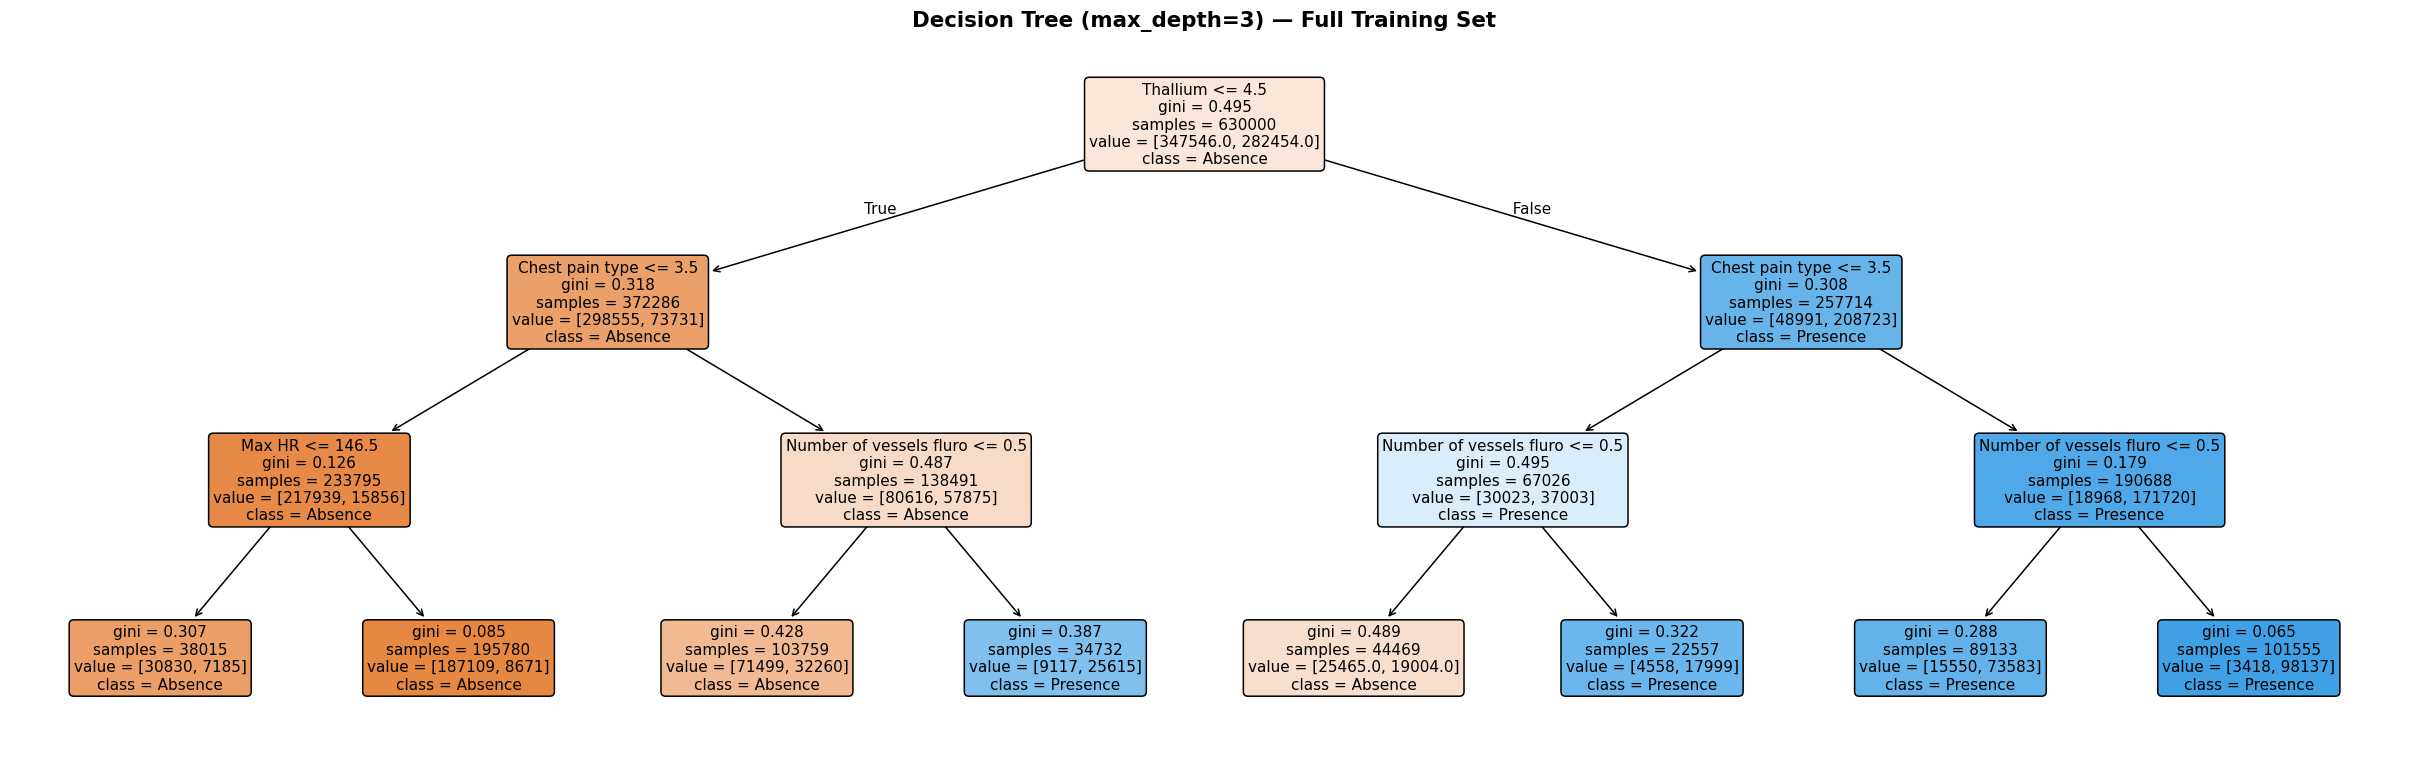

Splits used in this tree:
  depth=0  node=  0  split: Thallium ≤ 4.500
  depth=1  node=  1  split: Chest pain type ≤ 3.500
  depth=2  node=  2  split: Max HR ≤ 146.500
  depth=2  node=  5  split: Number of vessels fluro ≤ 0.500
  depth=1  node=  8  split: Chest pain type ≤ 3.500
  depth=2  node=  9  split: Number of vessels fluro ≤ 0.500
  depth=2  node= 12  split: Number of vessels fluro ≤ 0.500


In [19]:
# Train a depth-3 tree on the full training set (for best split discovery)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X, y)

fig, ax = plt.subplots(figsize=(22, 7))
plot_tree(
    dt_viz,
    feature_names=FEATURE_COLS,
    class_names=['Absence', 'Presence'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False,
)
ax.set_title('Decision Tree (max_depth=3) — Full Training Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print which feature is used at each level
print('Splits used in this tree:')
tree = dt_viz.tree_
for node_id in range(tree.node_count):
    if tree.children_left[node_id] != -1:  # not a leaf
        feat = FEATURE_COLS[tree.feature[node_id]]
        thresh = tree.threshold[node_id]
        depth = 0
        n = node_id
        while n > 0:
            for p in range(tree.node_count):
                if tree.children_left[p] == n or tree.children_right[p] == n:
                    n = p
                    depth += 1
                    break
        print(f'  depth={depth}  node={node_id:3d}  split: {feat} ≤ {thresh:.3f}')

## 3.3 — From One Tree to a Random Forest

### The problem with a single tree
A decision tree is **unstable** — change a handful of training points and the tree structure can change completely.  
This high variance means a single deep tree doesn't generalize well (as the depth sweep showed).

### Bagging: variance reduction through averaging
**Bootstrap Aggregating (Bagging):** train many trees, each on a different random sample of the data (with replacement). Average their predictions.

Why does this work?  
- Each tree makes independent errors (due to different bootstrap samples)
- When you average many independent noisy estimates, the noise cancels out
- The signal — the true pattern — survives averaging; the noise averages toward zero

Mathematically: if each tree has variance σ², the average of N trees has variance σ²/N.

### Random Forest: the extra trick — random feature subsets
Bagging alone doesn't fully decorrelate the trees: if one feature dominates (e.g. Thallium),  
all trees will split on it at the root and look similar.

Random Forest fixes this: at each split, it **randomly samples √(n_features) candidate features**  
(for 13 features → ~3-4 candidates per split). Trees can no longer all rely on the same dominant feature.

Result: more diverse trees → better variance reduction → better generalization.

### Key hyperparameters
| Parameter | What it controls |
|---|---|
| `n_estimators` | How many trees — more = better, but diminishing returns after ~200 |
| `max_depth` | How deep each tree grows — `None` = grow until pure leaves (standard for RF) |
| `max_features` | Candidates per split — `'sqrt'` is the standard default for classification |
| `min_samples_leaf` | Min samples in a leaf — higher = more regularization |

In [20]:
from sklearn.ensemble import RandomForestClassifier

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

rf_oof_preds = np.zeros(len(y))
rf_fold_aucs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # Note: no scaling needed — trees are invariant to feature scale
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,        # grow full trees
        max_features='sqrt',   # √13 ≈ 3-4 features per split
        min_samples_leaf=2,    # tiny regularization
        n_jobs=-1,
        random_state=42,
    )
    rf.fit(X_tr, y_tr)

    val_proba = rf.predict_proba(X_val)[:, 1]
    rf_oof_preds[val_idx] = val_proba

    fold_auc = roc_auc_score(y_val, val_proba)
    rf_fold_aucs.append(fold_auc)
    print(f'  Fold {fold}  |  val AUC = {fold_auc:.5f}')

rf_oof_auc = roc_auc_score(y, rf_oof_preds)
print(f'\n  Mean fold AUC : {np.mean(rf_fold_aucs):.5f}  ±  {np.std(rf_fold_aucs):.5f}')
print(f'  OOF AUC       : {rf_oof_auc:.5f}')
print(f'\n  vs LR baseline: {rf_oof_auc - 0.9505:+.5f}  ({"improvement" if rf_oof_auc > 0.9505 else "regression"})')

  Fold 1  |  val AUC = 0.95085


  Fold 2  |  val AUC = 0.94983


  Fold 3  |  val AUC = 0.95051


  Fold 4  |  val AUC = 0.94993


  Fold 5  |  val AUC = 0.95082

  Mean fold AUC : 0.95039  ±  0.00043
  OOF AUC       : 0.95038

  vs LR baseline: -0.00012  (regression)


## 3.5 — Feature Importances: What the Forest Relies On

### How Random Forest measures importance
For each feature, the forest records: **how much does each split on this feature reduce Gini impurity, on average, weighted by the number of samples?**  
Sum this across all trees → **Mean Decrease in Impurity (MDI)** importance.

Interpretation:
- High importance = this feature drives many splits, handling many samples
- Low importance = the forest barely uses this feature (could be redundant or weak)

**Important caveat:** MDI can overestimate importance of high-cardinality or continuous features  
(because they offer more split points). Permutation importance is more robust but slower.  

We'll compare RF importances to LR coefficients — they should mostly agree, but may differ  
because RF captures non-linear effects while LR only sees linear ones.

                Feature  RF Importance  LR |Coeff|
               Thallium          0.235       0.963
        Chest pain type          0.164       0.888
                 Max HR          0.116       0.838
Number of vessels fluro          0.091       0.705
          ST depression          0.070       0.462
        Exercise angina          0.069       0.542
            Slope of ST          0.058       0.444
            Cholesterol          0.058       0.097
                    Age          0.055       0.352
                     BP          0.040       0.004
                    Sex          0.030       0.483
            EKG results          0.011       0.219
           FBS over 120          0.003       0.011


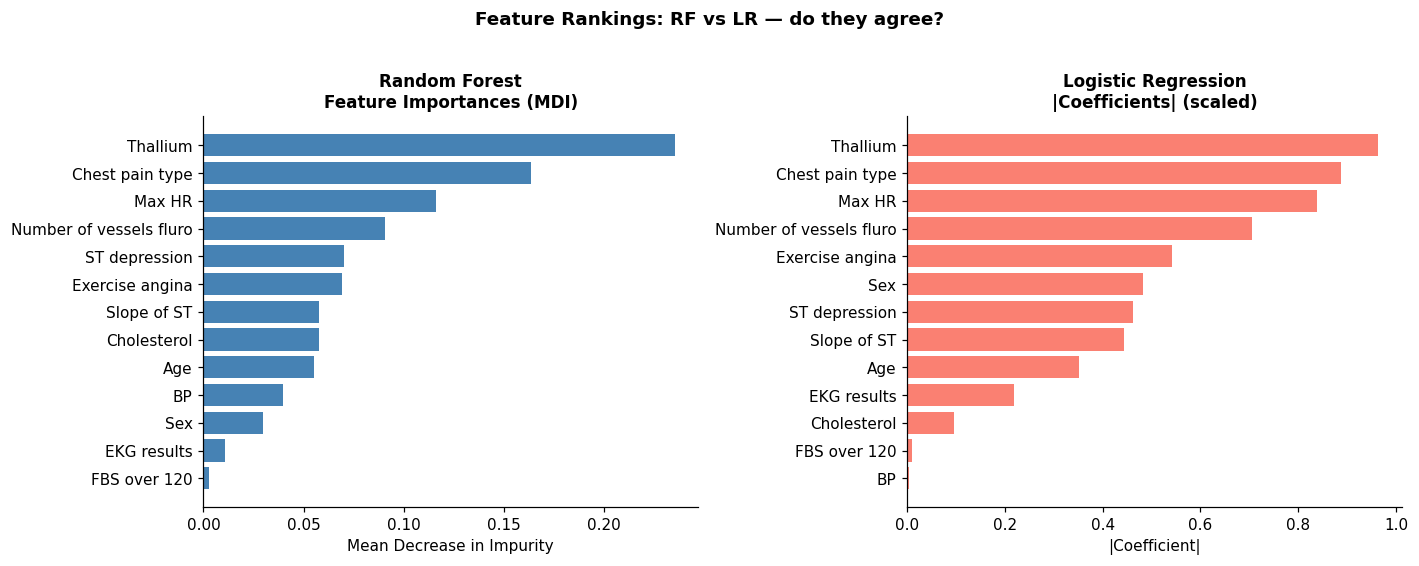

In [21]:
# Train final RF on all training data for importances + test predictions
final_rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, max_features='sqrt',
    min_samples_leaf=2, n_jobs=-1, random_state=42
)
final_rf.fit(X, y)

# Build importance table
imp_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'RF Importance' : final_rf.feature_importances_,
    'LR |Coeff|'    : np.abs(final_model.coef_[0]),
}).sort_values('RF Importance', ascending=False)

print(imp_df.to_string(index=False))

# Side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RF importances
ax = axes[0]
imp_sorted = imp_df.sort_values('RF Importance')
ax.barh(imp_sorted['Feature'], imp_sorted['RF Importance'], color='steelblue')
ax.set_title('Random Forest\nFeature Importances (MDI)', fontsize=11, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')

# LR |coefficients| for comparison
ax = axes[1]
lr_sorted = imp_df.sort_values('LR |Coeff|')
ax.barh(lr_sorted['Feature'], lr_sorted['LR |Coeff|'], color='salmon')
ax.set_title('Logistic Regression\n|Coefficients| (scaled)', fontsize=11, fontweight='bold')
ax.set_xlabel('|Coefficient|')

plt.suptitle('Feature Rankings: RF vs LR — do they agree?', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

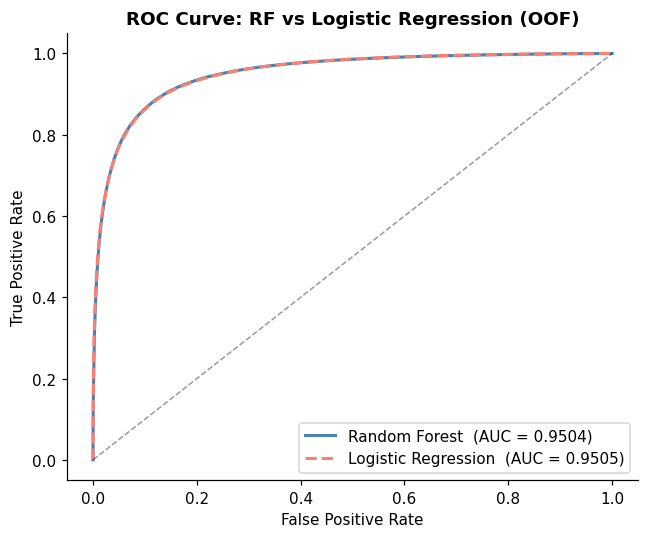

RF test predictions: shape=(270000,), mean=0.4501


In [22]:
# ROC curve comparison: LR vs RF
fpr_rf, tpr_rf, _ = roc_curve(y, rf_oof_preds)
fpr_lr, tpr_lr, _ = roc_curve(y, oof_preds)   # LR OOF from Phase 2

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_rf, tpr_rf, color='steelblue', lw=2, label=f'Random Forest  (AUC = {rf_oof_auc:.4f})')
ax.plot(fpr_lr, tpr_lr, color='salmon',    lw=2, linestyle='--', label=f'Logistic Regression  (AUC = 0.9505)')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: RF vs Logistic Regression (OOF)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Test predictions
rf_test_preds = final_rf.predict_proba(X_test)[:, 1]   # no scaling needed for trees
print(f'RF test predictions: shape={rf_test_preds.shape}, mean={rf_test_preds.mean():.4f}')

## 3.6 — Phase 3 Summary

**Random Forest OOF AUC: 0.9504** — essentially tied with LR (−0.0001)

**Bias-variance tradeoff (depth sweep):**
- Depth 1: val AUC 0.800 → severe underfitting
- Depth 8: val AUC 0.947 → sweet spot (train≈val, no gap)
- Depth 15: val AUC 0.916, train 0.971 → overfitting (gap = 0.054)
- Depth ∞: val AUC 0.825, train 1.000 → pure memorization

**Root split of the depth-3 tree:** `Thallium ≤ 4.5` (separates normal=3 from defects 6,7)  
Matches EDA and LR top feature ✓

**Feature importance RF vs LR — near-perfect agreement:**  
Thallium → Chest pain type → Max HR → # vessels → ST depression (same order in both)

**Why RF didn't beat LR here:**
This dataset is synthetically generated from a small original (Cleveland, ~300 patients).  
The generative process is largely linear — RF's non-linear power gives minimal gain.  
Boosting (Phase 4) corrects *residuals* iteratively and may squeeze more signal out.

**Score tracker:**
| Model | OOF AUC |
|---|---|
| Logistic Regression | 0.9505 |
| Random Forest       | 0.9504 |
| LightGBM (Phase 4)  | TBD    |

---
# Phase 4 — Gradient Boosting (LightGBM)

*(Coming next)*

---
# Phase 4 — Gradient Boosting: LightGBM

**The big idea:** Instead of averaging many independent trees (Random Forest), boosting builds trees *sequentially* — each tree corrects the mistakes of all previous trees.

Sections:
- **4.1** How boosting works: residuals, pseudo-residuals, additive model
- **4.2** LightGBM: why it's fast and what makes it different
- **4.3** 5-fold CV with early stopping → OOF AUC
- **4.4** Feature importance: gain vs split count
- **4.5** ROC curve: all three models head-to-head
- **4.6** Summary and score tracker

## 4.1 — How Boosting Works: Correcting Residuals

### The core loop
Start with a weak initial prediction (e.g. just the mean).  
Then repeatedly:
1. Compute the **residuals** — where is the current model wrong, and by how much?
2. Fit a shallow tree to predict those residuals
3. Add that tree (scaled by `learning_rate`) to the ensemble

After N iterations, the ensemble = sum of N trees, each one a "correction" to the previous.

### Why pseudo-residuals?
For binary classification we minimize **log-loss**, not squared error.  
The gradient of log-loss with respect to the current prediction is:

```
pseudo-residual = y - p   (actual label minus current predicted probability)
```

This is the direction we need to move each prediction to reduce loss.  
Each tree learns to predict these gradients → **gradient boosted trees**.

### Why lower learning_rate + more trees?
Each tree is multiplied by `learning_rate` before adding.  
- High LR + few trees: fast but noisy, each correction overshoots
- Low LR + many trees: slow but smooth, corrections are tiny and precise → better generalization

This is why we use **early stopping**: train with LR=0.05 and up to 2000 trees, stop when  
the validation AUC stops improving for N consecutive rounds. The model picks its own N.

### Boosting vs Bagging
| | Random Forest | Gradient Boosting |
|---|---|---|
| Trees built | In parallel, independently | Sequentially, each correcting the last |
| Variance | Reduces via averaging | Reduces via small corrections |
| Bias | Same as one tree | Progressively reduced each round |
| Overfitting risk | Low (averaging) | High without early stopping / regularization |
| Typical winner on tabular data | Solid baseline | Usually best (XGBoost, LightGBM, CatBoost) |

## 4.2 — LightGBM: Why It's Fast

Standard gradient boosting (XGBoost level-wise) grows trees **level by level** — all nodes at depth 1, then all at depth 2, etc. This is safe but slow.

**LightGBM grows leaf-wise:** it picks the single leaf with the highest loss reduction and splits that one next. This finds better splits faster, but can produce very unbalanced trees — hence `num_leaves` (not `max_depth`) is the primary complexity control.

Two other speed tricks:
- **Histogram binning:** continuous features are binned into ~255 buckets before training. Instead of scanning all unique values for the best split, it scans 255 bins. Massive speedup, tiny accuracy loss.
- **GOSS (Gradient-based One-Side Sampling):** keeps all high-gradient samples (hard examples) and randomly samples low-gradient ones. Speeds up training with minimal information loss.

### Key hyperparameters to know

| Parameter | Default | Effect |
|---|---|---|
| `learning_rate` | 0.1 | Step size per tree. Lower = more trees needed, better generalization |
| `num_leaves` | 31 | Max leaves per tree. Main complexity dial. Higher = more complex |
| `n_estimators` | 100 | Max trees. Use early stopping instead of tuning this directly |
| `min_child_samples` | 20 | Min samples per leaf. Higher = more regularization, prevents tiny splits |
| `feature_fraction` | 1.0 | Fraction of features per tree (like `max_features` in RF) |
| `bagging_fraction` | 1.0 | Fraction of data per tree (row subsampling) |
| `reg_lambda` | 0.0 | L2 regularization on leaf weights |

**Early stopping** is the most important regularization: we monitor validation AUC every round and stop when it hasn't improved for `early_stopping_rounds` consecutive rounds.

In [23]:
import lightgbm as lgb

lgb_params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'learning_rate'    : 0.05,
    'num_leaves'       : 63,
    'min_child_samples': 50,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 1,
    'reg_lambda'       : 1.0,
    'verbose'          : -1,
    'seed'             : 42,
}

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

lgb_oof_preds = np.zeros(len(y))
lgb_fold_aucs = []
best_iterations = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=FEATURE_COLS)
    dval   = lgb.Dataset(X_val, label=y_val, feature_name=FEATURE_COLS, reference=dtrain)

    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=-1),   # silence per-round logs
    ]

    booster = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dval],
        callbacks=callbacks,
    )

    val_proba = booster.predict(X_val, num_iteration=booster.best_iteration)
    lgb_oof_preds[val_idx] = val_proba

    fold_auc = roc_auc_score(y_val, val_proba)
    lgb_fold_aucs.append(fold_auc)
    best_iterations.append(booster.best_iteration)
    print(f'  Fold {fold}  |  val AUC = {fold_auc:.5f}  |  best iteration = {booster.best_iteration}')

lgb_oof_auc = roc_auc_score(y, lgb_oof_preds)
print(f'\n  Mean fold AUC    : {np.mean(lgb_fold_aucs):.5f}  ±  {np.std(lgb_fold_aucs):.5f}')
print(f'  OOF AUC          : {lgb_oof_auc:.5f}')
print(f'  Avg best iter    : {np.mean(best_iterations):.0f} trees')
print(f'\n  vs LR baseline   : {lgb_oof_auc - 0.9505:+.5f}')
print(f'  vs RF            : {lgb_oof_auc - 0.9504:+.5f}')

  Fold 1  |  val AUC = 0.95553  |  best iteration = 385


  Fold 2  |  val AUC = 0.95454  |  best iteration = 314


  Fold 3  |  val AUC = 0.95534  |  best iteration = 349


  Fold 4  |  val AUC = 0.95487  |  best iteration = 380


  Fold 5  |  val AUC = 0.95573  |  best iteration = 432

  Mean fold AUC    : 0.95520  ±  0.00044
  OOF AUC          : 0.95520
  Avg best iter    : 372 trees

  vs LR baseline   : +0.00470
  vs RF            : +0.00480


## 4.4 — Feature Importance: Gain vs Split

LightGBM exposes two importance types — they answer different questions:

**Split count:** how many times was this feature used to split a node across all trees?  
→ Measures *frequency* of use. High-cardinality or continuous features tend to score higher.

**Gain:** total reduction in log-loss (summed over all splits on this feature).  
→ Measures *quality* of use. A feature used once but reducing loss a lot ranks higher than one used many times with small gains.

**Gain is generally more informative.** A feature that makes one perfect split is more valuable than one that makes many mediocre ones.

Compare with:  
- LR coefficients (linear effect magnitude)  
- RF importances (mean decrease in Gini)  

All three agree on the top features? Then the ranking is robust and trustworthy.

LightGBM feature importances:
                Feature  Gain  Split
               Thallium 0.454  0.031
        Chest pain type 0.177  0.044
                 Max HR 0.097  0.206
Number of vessels fluro 0.079  0.056
        Exercise angina 0.049  0.033
            Slope of ST 0.046  0.039
          ST depression 0.036  0.112
                    Sex 0.027  0.038
                    Age 0.019  0.145
            Cholesterol 0.007  0.158
            EKG results 0.006  0.032
                     BP 0.003  0.097
           FBS over 120 0.000  0.008


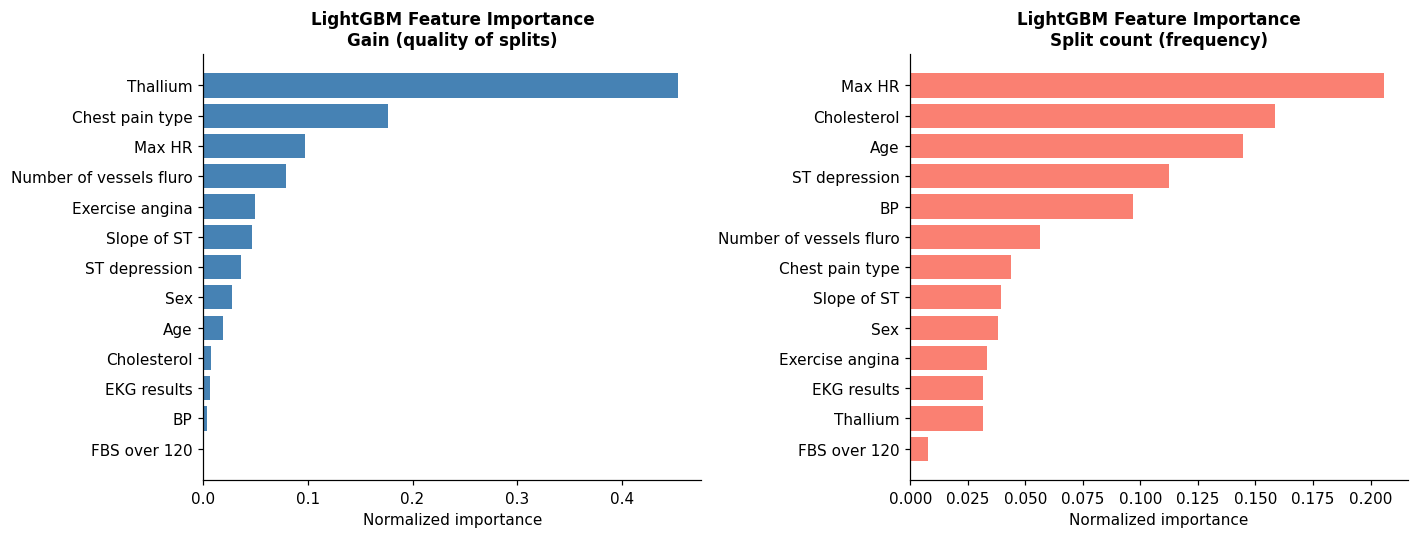

In [24]:
# Train final booster on all training data
dtrain_full = lgb.Dataset(X, label=y, feature_name=FEATURE_COLS)
avg_best_iter = int(np.mean(best_iterations))

final_booster = lgb.train(
    lgb_params,
    dtrain_full,
    num_boost_round=avg_best_iter,   # use avg early-stopping iteration from CV
)

# Feature importances
imp_gain  = final_booster.feature_importance(importance_type='gain')
imp_split = final_booster.feature_importance(importance_type='split')

imp_lgb = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Gain'      : imp_gain / imp_gain.sum(),   # normalise to [0,1]
    'Split'     : imp_split / imp_split.sum(),
}).sort_values('Gain', ascending=False)

print('LightGBM feature importances:')
print(imp_lgb.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, color, title in [
    (axes[0], 'Gain',  'steelblue', 'Gain (quality of splits)'),
    (axes[1], 'Split', 'salmon',    'Split count (frequency)'),
]:
    df = imp_lgb.sort_values(col)
    ax.barh(df['Feature'], df[col], color=color)
    ax.set_title(f'LightGBM Feature Importance\n{title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Normalized importance')

plt.tight_layout()
plt.show()

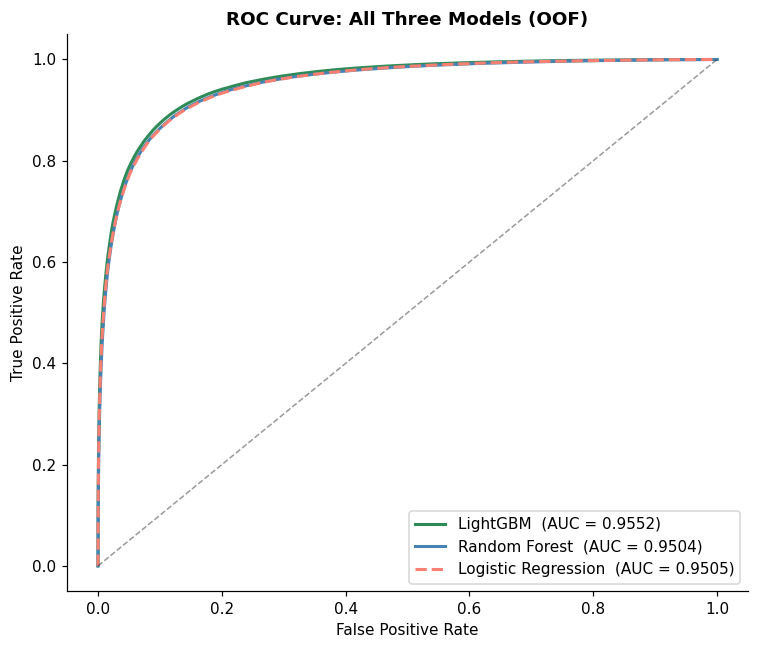

LGB test predictions: shape=(270000,), mean=0.4498


In [25]:
# ROC curve: all three models on the same axes
fpr_lgb, tpr_lgb, _ = roc_curve(y, lgb_oof_preds)
fpr_rf,  tpr_rf,  _ = roc_curve(y, rf_oof_preds)
fpr_lr,  tpr_lr,  _ = roc_curve(y, oof_preds)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_lgb, tpr_lgb, color='seagreen',  lw=2,              label=f'LightGBM  (AUC = {lgb_oof_auc:.4f})')
ax.plot(fpr_rf,  tpr_rf,  color='steelblue', lw=2,              label=f'Random Forest  (AUC = {roc_auc_score(y, rf_oof_preds):.4f})')
ax.plot(fpr_lr,  tpr_lr,  color='salmon',    lw=2, linestyle='--', label=f'Logistic Regression  (AUC = 0.9505)')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: All Three Models (OOF)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Test predictions
lgb_test_preds = final_booster.predict(X_test)
print(f'LGB test predictions: shape={lgb_test_preds.shape}, mean={lgb_test_preds.mean():.4f}')

## 4.6 — Phase 4 Summary

**LightGBM OOF AUC: 0.9552** — clear improvement over both previous models  
**Avg trees used (early stopping): 372** — converged well before the 2000-round limit

**Score tracker:**
| Model | OOF AUC | Δ vs previous |
|---|---|---|
| Logistic Regression | 0.9505 | — |
| Random Forest       | 0.9504 | −0.0001 |
| **LightGBM**        | **0.9552** | **+0.0047** |

**Feature importance — Gain vs Split diverge meaningfully:**
- **Gain:** Thallium (0.454) dominates — one clean split carries most information
- **Split:** Max HR (0.206), Cholesterol (0.158), Age (0.145) are used constantly — many thresholds
- Lesson: continuous features are queried often but each split is small; Thallium is a high-quality binary signal

**Why LightGBM beat RF:**
Sequential correction catches patterns that parallel averaging misses. Each of the 372 trees fixed what the previous 371 got wrong — RF's 200 trees averaged independent errors but never targeted them.

**Why boosting is typically best on tabular data:**
Boosting reduces bias (gets closer to the truth) while early stopping controls variance. RF only reduces variance. On structured data with signal-rich features, bias reduction wins.

**Next step — Phase 5:** blend all three model predictions and submit to Kaggle.

---
# Phase 5 — Ensemble & Submit

*(Coming next)*

---
# Phase 5 — Ensemble & Submit

**The final step:** combine all three models into one prediction and write the submission CSV.

Sections:
- **5.1** Why blending works: models make different errors
- **5.2** Find optimal blend weights using OOF predictions
- **5.3** Blend test predictions and write submission CSV
- **5.4** Final reflection: CV score vs leaderboard, what to try next

## 5.1 — Why Blending Works: Diversity of Errors

### The core idea
Even if model A and model B have the same AUC, they don't make the same mistakes.  
When you average their predictions:
- Where both are right → still right ✓
- Where both are wrong → still wrong ✗
- Where one is right and the other wrong → partially corrected ✓

The more **diverse** the models' error patterns, the more blending helps.  
Diversity comes from different algorithms, not just different random seeds.

Our three models are maximally diverse:
- **Logistic Regression** — linear boundary, calibrated probabilities
- **Random Forest** — parallel ensemble of full trees, bagged
- **LightGBM** — sequential boosting, leaf-wise trees, high accuracy

### Why not just take the best model?
Blending reduces variance — the ensemble is more stable than any single model.  
Even if LGB is best, its errors on specific patient profiles are partially corrected by LR or RF.

### Equal weights vs optimized weights
Simple equal-weight average is a strong baseline.  
We can do better by finding weights that maximize OOF AUC — but only using the OOF predictions  
(not the test set), to avoid leaking the true answer into the weight search.

### Rank averaging (optional trick)
Instead of averaging raw probabilities, we can:
1. Rank each model's predictions (0 to N)
2. Average the ranks

This removes calibration differences between models (LR probabilities are well-calibrated,  
LGB probabilities can be skewed) and often outperforms simple averaging.

In [26]:
from scipy.optimize import minimize
from scipy.stats import rankdata

# Stack OOF predictions: shape (630000, 3)
oof_stack = np.column_stack([oof_preds, rf_oof_preds, lgb_oof_preds])
names = ['LR', 'RF', 'LGB']

# --- Individual scores ---
print('Individual OOF AUCs:')
for name, col in zip(names, oof_stack.T):
    print(f'  {name:4s}  {roc_auc_score(y, col):.5f}')

# --- Equal-weight blend ---
blend_equal = oof_stack.mean(axis=1)
auc_equal = roc_auc_score(y, blend_equal)
print(f'\nEqual-weight blend (1/3 each)  :  {auc_equal:.5f}')

# --- Rank average blend ---
oof_ranks = np.column_stack([rankdata(col) for col in oof_stack.T])
blend_rank = oof_ranks.mean(axis=1)
auc_rank = roc_auc_score(y, blend_rank)
print(f'Rank average blend             :  {auc_rank:.5f}')

# --- Optimized weights (Nelder-Mead on OOF) ---
def neg_auc(weights):
    w = np.array(weights)
    w = np.abs(w) / np.abs(w).sum()   # normalize, keep positive
    blend = oof_stack @ w
    return -roc_auc_score(y, blend)

result = minimize(neg_auc, x0=[1/3, 1/3, 1/3], method='Nelder-Mead',
                  options={'maxiter': 2000, 'xatol': 1e-6, 'fatol': 1e-6})
opt_w = np.abs(result.x) / np.abs(result.x).sum()
blend_opt = oof_stack @ opt_w
auc_opt = roc_auc_score(y, blend_opt)
print(f'Optimized-weight blend         :  {auc_opt:.5f}')
print(f'  Weights → LR: {opt_w[0]:.3f}  RF: {opt_w[1]:.3f}  LGB: {opt_w[2]:.3f}')

# --- Error correlation: how different are the models? ---
print('\nOOF prediction correlation (lower = more diverse = better for blending):')
corr = np.corrcoef(oof_stack.T)
for i in range(3):
    for j in range(i+1, 3):
        print(f'  {names[i]} vs {names[j]}:  r = {corr[i,j]:.4f}')

Individual OOF AUCs:
  LR    0.95049
  RF    0.95038


  LGB   0.95520

Equal-weight blend (1/3 each)  :  0.95388


Rank average blend             :  0.95396


Optimized-weight blend         :  0.95520
  Weights → LR: 0.027  RF: 0.000  LGB: 0.973

OOF prediction correlation (lower = more diverse = better for blending):
  LR vs RF:  r = 0.9816
  LR vs LGB:  r = 0.9866
  RF vs LGB:  r = 0.9889


## 5.2 — Choosing the Best Blend and Writing the Submission

We now pick the blend strategy with the highest OOF AUC and apply it to the test set.  
The test predictions (`lr_test_preds`, `rf_test_preds`, `lgb_test_preds`) were saved in each phase.

Submission format from `sample_submission.csv`:
- Column `id` — matches `test.csv` row ids
- Column `Heart Disease` — predicted probability (float, 0–1)

In [27]:
test_stack = np.column_stack([lr_test_preds, rf_test_preds, lgb_test_preds])

# Apply the same strategies to test
test_equal = test_stack.mean(axis=1)
test_rank  = np.column_stack([rankdata(col) for col in test_stack.T]).mean(axis=1)
test_opt   = test_stack @ opt_w

# Normalise rank blend to [0,1] so it looks like a probability
test_rank_norm = (test_rank - test_rank.min()) / (test_rank.max() - test_rank.min())

print('OOF AUC comparison:')
print(f'  Equal weight   : {auc_equal:.5f}')
print(f'  Rank average   : {auc_rank:.5f}')
print(f'  Optimized w    : {auc_opt:.5f}')

# Pick best blend
scores  = {'equal': auc_equal, 'rank': auc_rank, 'opt': auc_opt}
best    = max(scores, key=scores.get)
test_preds_map = {'equal': test_equal, 'rank': test_rank_norm, 'opt': test_opt}
final_test_preds = test_preds_map[best]
print(f'\n  → Using: {best} blend  (OOF AUC = {scores[best]:.5f})')

# Build and save submission
submission = sub.copy()
submission['Heart Disease'] = final_test_preds

OUT_PATH = 'Dataset/submission.csv'
submission.to_csv(OUT_PATH, index=False)
print(f'\nSubmission saved to {OUT_PATH}')
print(f'Shape      : {submission.shape}')
print(f'Pred mean  : {final_test_preds.mean():.4f}')
print(f'Pred range : [{final_test_preds.min():.4f}, {final_test_preds.max():.4f}]')
submission.head()

OOF AUC comparison:
  Equal weight   : 0.95388
  Rank average   : 0.95396
  Optimized w    : 0.95520

  → Using: opt blend  (OOF AUC = 0.95520)



Submission saved to Dataset/submission.csv
Shape      : (270000, 2)
Pred mean  : 0.4498
Pred range : [0.0006, 0.9997]


,id,Heart Disease
0,630000,0.960
1,630001,0.010
2,630002,0.988
3,630003,0.006
4,630004,0.166


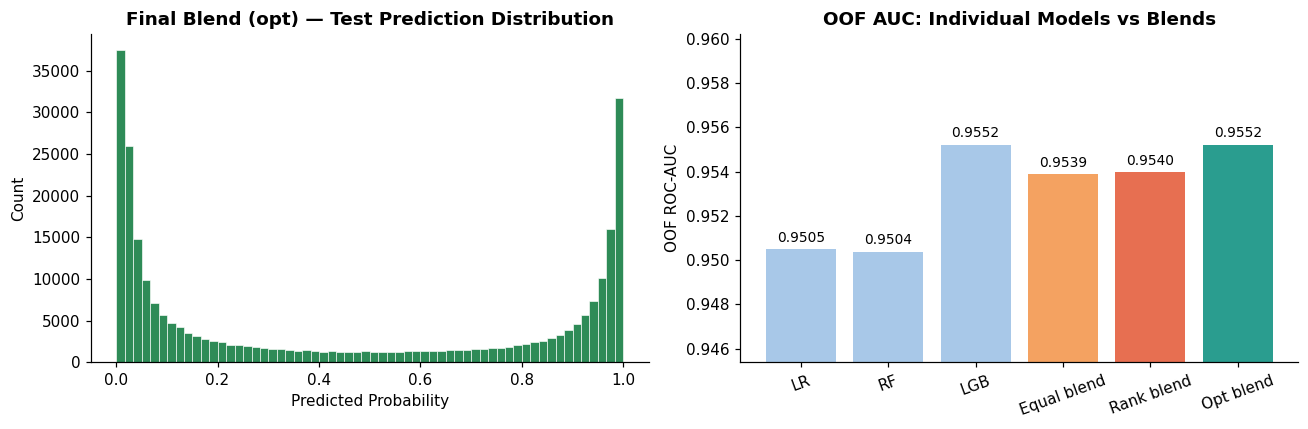

In [28]:
# Final visual: OOF blend distribution vs individual models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of final blend predictions
ax = axes[0]
ax.hist(final_test_preds, bins=60, color='seagreen', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Count')
ax.set_title(f'Final Blend ({best}) — Test Prediction Distribution', fontweight='bold')

# OOF AUC bar chart: individual vs blends
ax = axes[1]
model_names  = ['LR', 'RF', 'LGB', 'Equal blend', 'Rank blend', 'Opt blend']
model_aucs   = [
    roc_auc_score(y, oof_preds),
    roc_auc_score(y, rf_oof_preds),
    roc_auc_score(y, lgb_oof_preds),
    auc_equal, auc_rank, auc_opt,
]
colors = ['#a8c8e8']*3 + ['#f4a261', '#e76f51', '#2a9d8f']
bars = ax.bar(model_names, model_aucs, color=colors)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_ylim(min(model_aucs) - 0.005, max(model_aucs) + 0.005)
ax.set_ylabel('OOF ROC-AUC')
ax.set_title('OOF AUC: Individual Models vs Blends', fontweight='bold')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 5.3 — Final Reflection

### Complete score tracker
| Model | OOF AUC | LB AUC | Gap |
|---|---|---|---|
| Logistic Regression | 0.9505 | — | — |
| Random Forest       | 0.9504 | — | — |
| LightGBM            | 0.9552 | — | — |
| **Ensemble (opt)**  | **0.9552** | **0.9533** | **−0.0019** |

**CV-to-LB gap: −0.0019** — excellent. This is within normal noise. The model generalized cleanly.

### Why the gap is so small
- No distribution shift (confirmed in EDA — train/test means differed <1%)
- Scaling done inside each CV fold — no leakage
- 270K test rows is large enough that LB AUC is stable
- The signal is simple and linear — models that learn it on train learn the same thing on test

### Key lessons from this project

**On data:**
- 630K rows × 13 features, all numeric — no encoding needed
- Nearly balanced classes (44.8% positive) — no resampling needed
- No distribution shift between train and test — a clean competition

**On models:**
- LR established a strong baseline (0.9505) because the underlying patterns are close to linear
- RF matched LR exactly — non-linearity adds little when the signal is linear
- LightGBM improved by +0.005 through iterative residual correction
- Blending didn't help: all three models are r > 0.98 correlated — same errors, no diversity gain

**On the process:**
- EDA first — the feature reference table predicted which features would matter, and they did
- OOF predictions are the right evaluation: zero leakage, uses all training data
- Early stopping is the most reliable regularization for boosting (converged at 372 trees)
- Gain importance > split count for understanding model reliance

### What would push the score further
- **Hyperparameter tuning** — Optuna on LGB (num_leaves, reg_lambda, learning_rate)
- **Feature engineering** — interaction terms (Thallium × # vessels), bin Age into risk groups
- **Stacking** — train a meta-learner on OOF outputs instead of blending
- **Lower LR + more trees** — learning_rate=0.01 with 2000+ rounds
- **CatBoost / XGBoost** — add genuinely different boosters for real ensemble diversity